1. Import Libraries


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')



2. Load Dataset

In [85]:
df=pd.read_csv('../data/TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


3. Understand Data

In [86]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


4. Data Cleaning

In [87]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [88]:

df.ffill(inplace=True)
df.drop_duplicates(inplace=True)

5. Date Processing

In [89]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [90]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

6. Exploratory Data Analysis

Tesla Closing Price Over Time

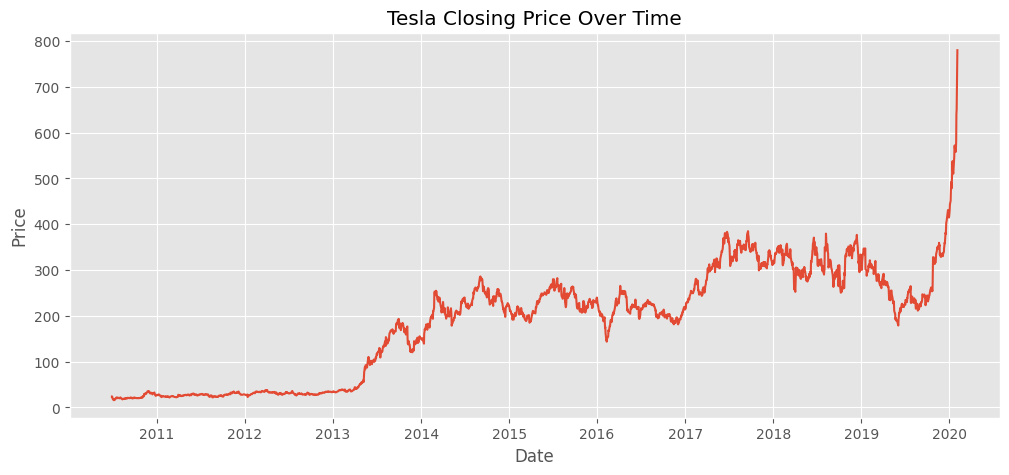

In [91]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Trading Volume Over Time

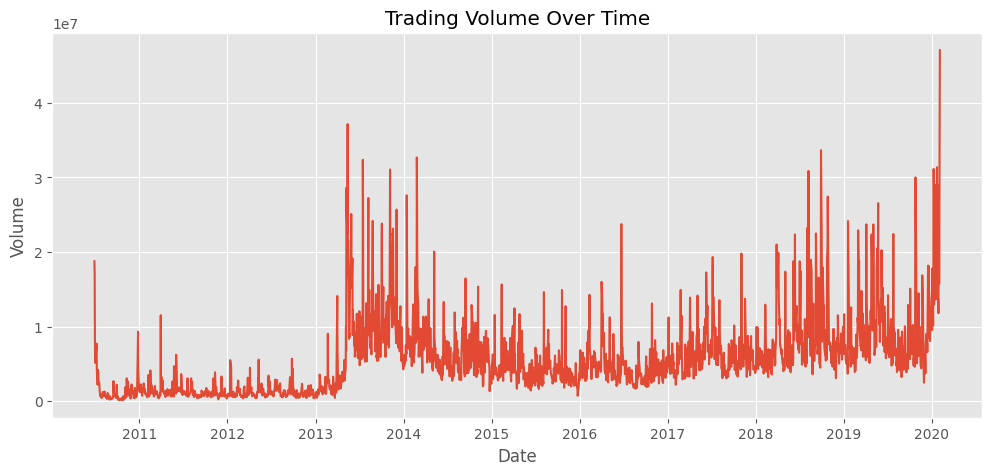

In [92]:
plt.figure(figsize=(12,5))
plt.plot(df['Volume'])
plt.title("Trading Volume Over Time")
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

Daily Returns



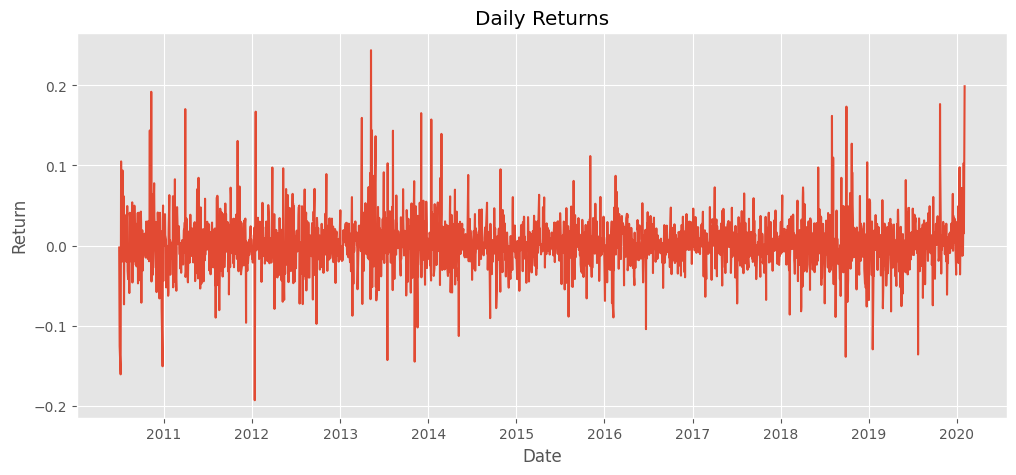

In [93]:
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(12,5))
plt.plot(df['Daily Return'])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

Volatility



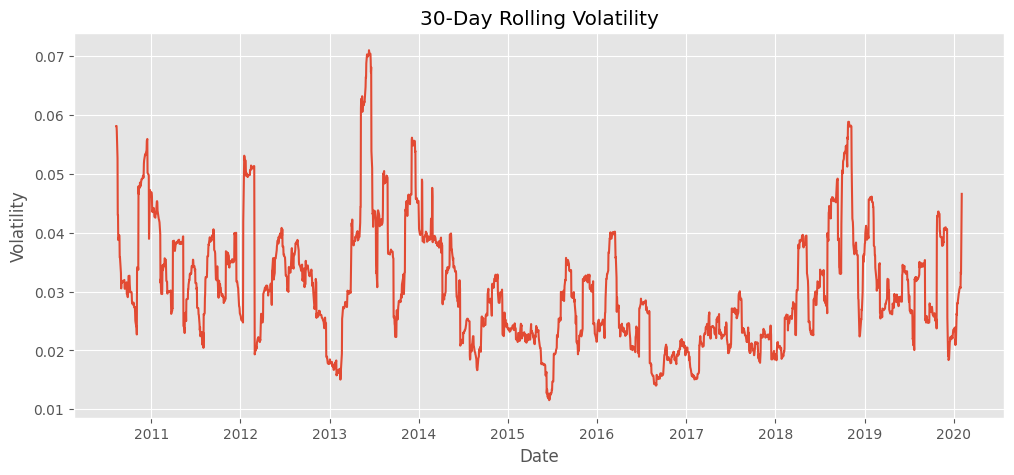

In [94]:
df['Volatility'] = df['Daily Return'].rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(df['Volatility'])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

Log Returns

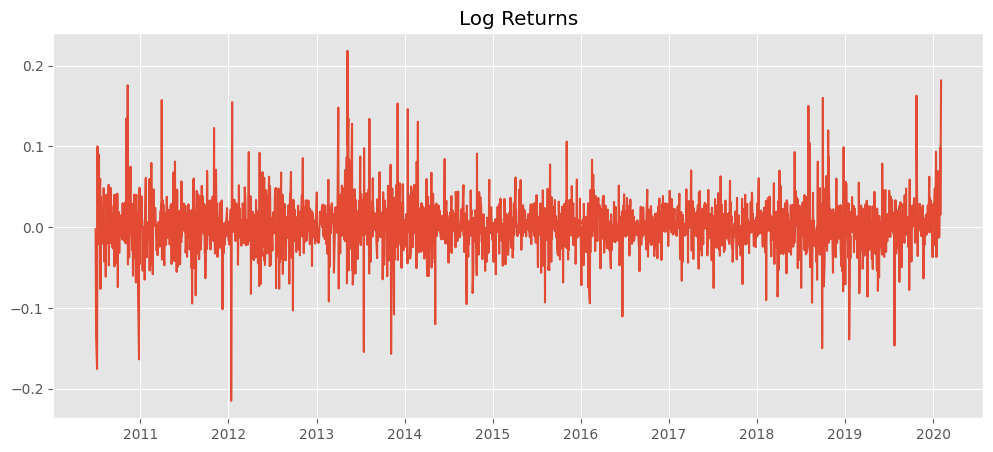

In [95]:
df['Log Return'] = np.log(df['Close'] / df['Close'].shift(1))

plt.figure(figsize=(12,5))
plt.plot(df['Log Return'])
plt.title("Log Returns")
plt.show()

Moving Averages



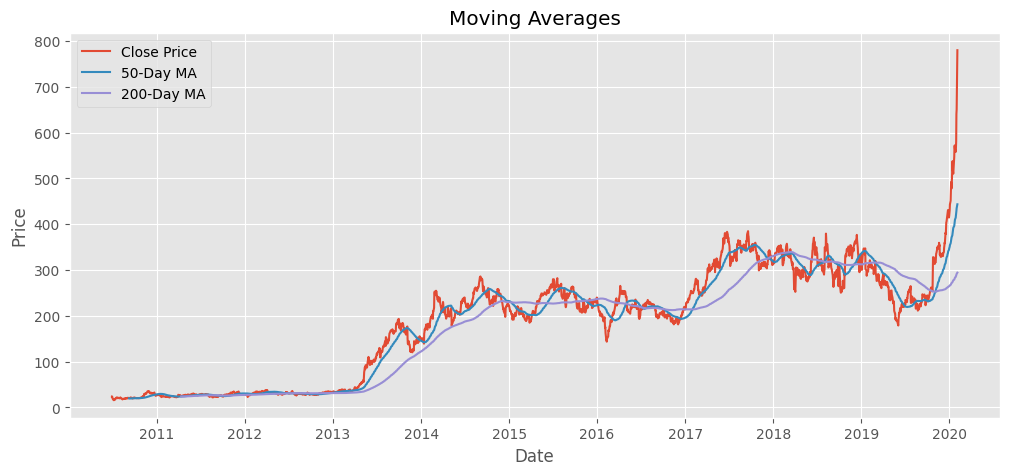

In [96]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50-Day MA')
plt.plot(df['MA200'], label='200-Day MA')
plt.legend()
plt.title("Moving Averages")
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

Distribution

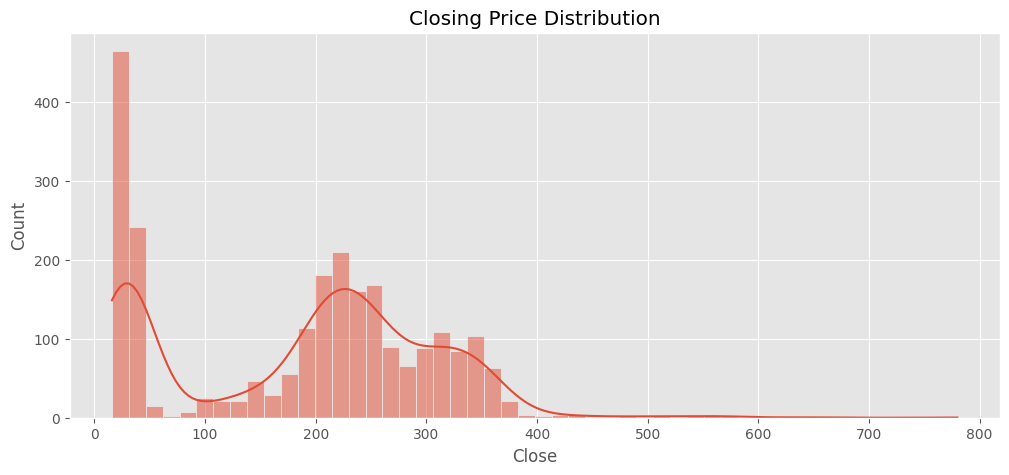

In [97]:
plt.figure(figsize=(12,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Closing Price Distribution")
plt.show()

Correlation Heatmap

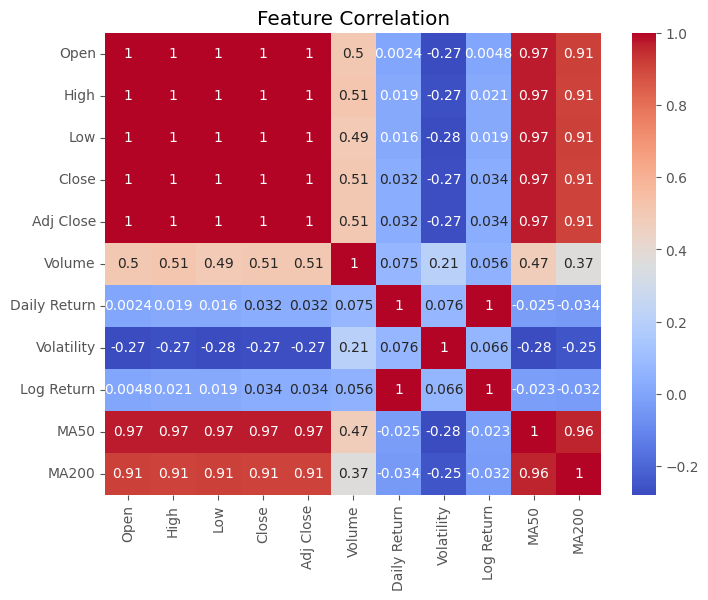

In [98]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

7. Insights Section

# Insights
- Tesla stock exhibits a strong upward trend over the observed period, indicating long-term growth.
- Significant volatility is observed, especially during certain market events.
- Closing price shows a very high correlation with Open, High, and Low prices, which is expected in stock data.
- Volume spikes indicate periods of high trading activity, possibly due to market news or events.
- Moving averages (50-day and 200-day) help identify bullish and bearish trends.
- Daily returns highlight short-term fluctuations and risk in stock price movement.
- Rolling volatility indicates changing market uncertainty over time.

8. Save Clean Data

In [99]:
df.to_csv('../data/cleaned_TSLA.csv')   

Prepare data for Deep Learning models

- Converted data → time series format
- Prepared input for RNN/LSTM
- Ready for deep learning

1. Load Clean Data

In [100]:
df = pd.read_csv('../data/cleaned_TSLA.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df


,Open,High,Low,Close,Adj Close,Volume,Daily Return,Volatility,Log Return,MA50,MA200
Date,,,,,,,,,,,
2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300,NaN,NaN,NaN,NaN,NaN
2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,-0.002511,NaN,-0.002515,NaN,NaN
2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,-0.078473,NaN,-0.081723,NaN,NaN
2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,-0.125683,NaN,-0.134312,NaN,NaN
2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,-0.160937,NaN,-0.175470,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,0.015913,0.030752,0.015788,418.773402,286.456801
2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,0.024854,0.030574,0.024551,423.406202,288.023250
2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,0.102962,0.033331,0.097999,429.179001,289.895400


In [101]:
df.isna().sum()

Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
Daily Return      1
Volatility       30
Log Return        1
MA50             49
MA200           199
dtype: int64

2. Select Feature

In [102]:
data = df[['Close']]
data

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
...,...
2020-01-28,566.900024
2020-01-29,580.989990
2020-01-30,640.809998


3. Scaling

In [103]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

4. Create Sequences

In [104]:
def create_dataset(data, time_step=60):
    X, Y= [], []
    for i in range(len(data)-time_step):
        X.append(data[i:i+time_step])
        Y.append(data[i+time_step])
    return np.array(X), np.array(Y) 

X, Y = create_dataset(scaled_data)

print(X.shape, Y.shape)


(2356, 60, 1) (2356, 1)


5. Train/Test Split

In [105]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]


6. Check Shape

In [106]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1884, 60, 1)
Y_train shape: (1884, 1)


Import Deep Learning Libraries

1. SimpleRNN Model

In [107]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout

model_rnn = Sequential([
    Input(shape=(60, 1)),
    SimpleRNN(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, Y_train, epochs=20, batch_size=32)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0081
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.4835e-04
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 8.7727e-04
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.3667e-04
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 7.1733e-04
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.7407e-04
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.1389e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.9808e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.2270e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.6755e-04
Epoch 12/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.3847e-04
Epoch 13/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.7584e-04
Epoch 14/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.1118e-04
Epoch 15/20
59/59 ━━━━━

2. LSTM Model

In [108]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Input(shape=(60, 1)),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0059 - val_loss: 0.0012
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 8.7242e-04 - val_loss: 0.0011
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 6.7738e-04 - val_loss: 0.0011
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6.0195e-04 - val_loss: 0.0012
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 5.7344e-04 - val_loss: 0.0010
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 5.4214e-04 - val_loss: 0.0010
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 5.0851e-04 - val_loss: 9.5286e-04
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.1279e-04 - val_loss: 9.9884e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.7308e-04 - val_loss: 9.0473e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 4.3106e-04 - val_loss: 9.7852e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 4.2328e-04 - val_loss: 9.6698e-04
Epo

Predictions

In [109]:
pred_rnn  = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1,1))
pred_lstm = scaler.inverse_transform(pred_lstm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


Visualization

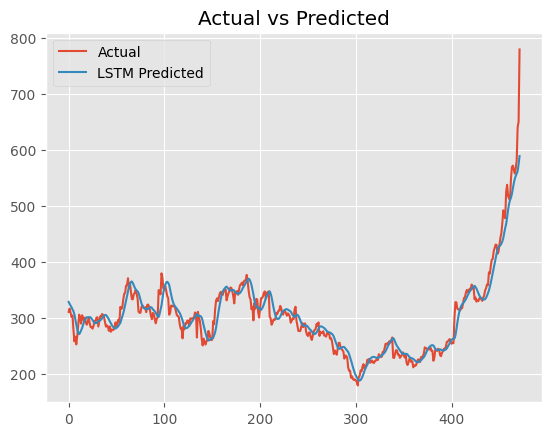

In [110]:
plt.plot(Y_test_actual, label='Actual')
plt.plot(pred_lstm, label='LSTM Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [111]:
from sklearn.metrics import mean_squared_error

# RNN
pred_rnn = scaler.inverse_transform(pred_rnn)
mse_rnn = mean_squared_error(Y_test_actual, pred_rnn)

# LSTM
mse_lstm = mean_squared_error(Y_test_actual, pred_lstm)

print("RNN MSE:", mse_rnn)
print("LSTM MSE:", mse_lstm)

RNN MSE: 337.66218238295374
LSTM MSE: 414.2606667829214


In [112]:
model_lstm.save('../models/tesla_lstm_model.h5')

- LSTM performs better than SimpleRNN due to its ability to capture long-term dependencies.
- SimpleRNN struggles with vanishing gradient problem.

Multi Day Predictions


In [113]:
def predict_future(model, last_data, days):
    temp_input = list(last_data)
    output = []
    for _ in range(days):
        x_input = np.array(temp_input[-60:]).reshape(1, 60, 1)
        pred = model.predict(x_input, verbose=0)
        temp_input.append(pred[0])
        output.append(pred[0])
    return scaler.inverse_transform(output)
    

In [114]:
last_60_days = scaled_data[-60:]

pred_1_day = predict_future(model_lstm, last_60_days, 1)
pred_5_days = predict_future(model_lstm, last_60_days, 5)
pred_10_days = predict_future(model_lstm, last_60_days, 10) 

print("Predicted price for next day:", pred_1_day)
print("Predicted prices for next 5 days:", pred_5_days)
print("Predicted prices for next 10 days:", pred_10_days)   


Predicted price for next day: [[621.23187579]]
Predicted prices for next 5 days: [[621.23187579]
 [635.30186609]
 [643.39425591]
 [647.59655023]
 [649.05692459]]
Predicted prices for next 10 days: [[621.23187579]
 [635.30186609]
 [643.39425591]
 [647.59655023]
 [649.05692459]
 [648.53975137]
 [646.58138028]
 [643.56588782]
 [639.77363343]
 [635.41314442]]


visualition

Predicated closing prices for 5 days

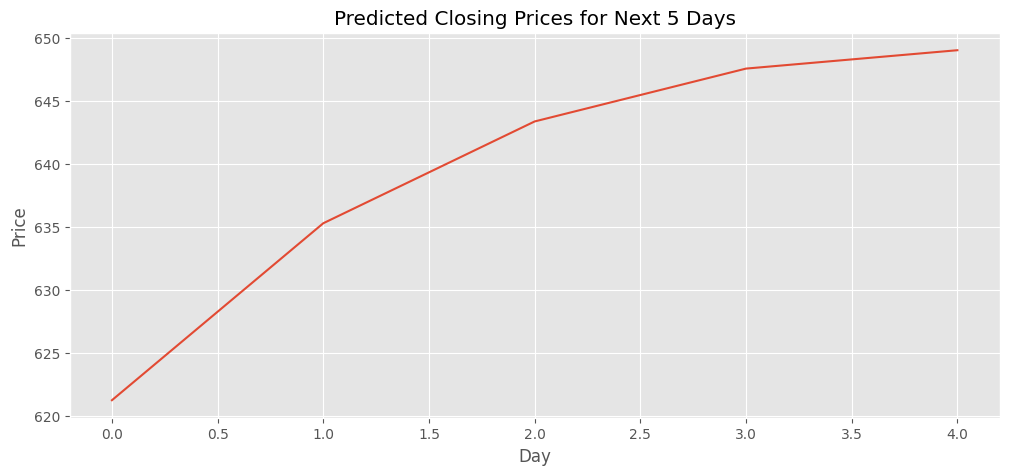

In [115]:
plt.figure(figsize=(12,5))
plt.plot(pred_5_days)
plt.title("Predicted Closing Prices for Next 5 Days")
plt.xlabel("Day")
plt.ylabel("Price")
plt.show()

Predicated closing prices for 50 days

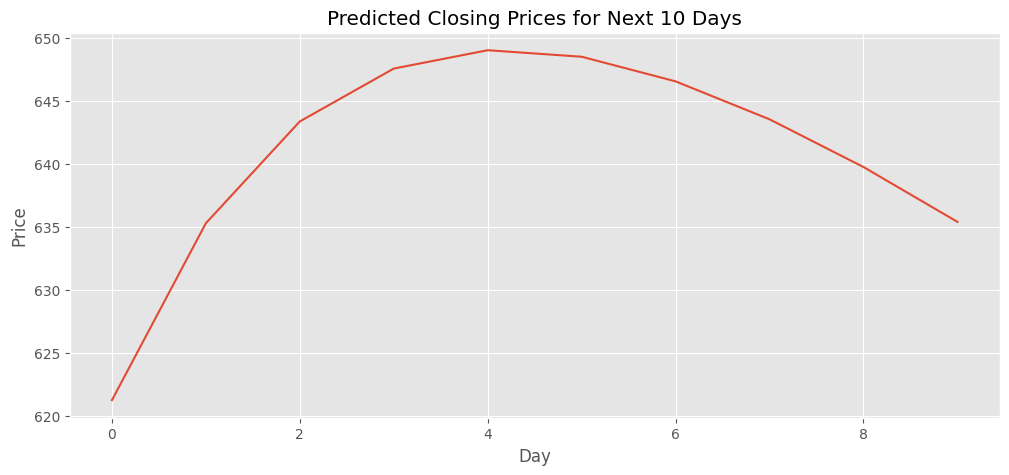

In [116]:
plt.figure(figsize=(12,5))
plt.plot(pred_10_days)
plt.title("Predicted Closing Prices for Next 10 Days")
plt.xlabel("Day")
plt.ylabel("Price")
plt.show()

In [117]:
np.save('../models/pred_1_day.npy', pred_1_day)
np.save('../models/pred_5_days.npy', pred_5_days)
np.save('../models/pred_10_days.npy', pred_10_days)
